# Test 14: Регулируемый K + Квантование — управляемое сжатие

**Идея:** K в top-k управляет разреженностью, биты квантования управляют точностью. Два ползунка — как качество в JPEG.

**План:**
- Обучить одну модель Chaos a=1 с K=64 (максимальный)
- После обучения менять K при инференсе: K ∈ {4, 8, 16, 32, 64}
- На каждом K квантовать до 2, 4, 8, 32 бит
- Построить полную rate-distortion карту
- Сравнить с TopK+ReLU

**Метрики:** compression ratio, MSE, PSNR, dead neurons

**Данные:** MNIST, N=5 прогонов

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# === Базовые компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def make_chaos_activation(a=1.0, w=0.5, b=4.0):
    @tf.function
    def activation(x):
        return tf.sin(a * x) + w * tf.tanh(b * x)
    return activation


def build_chaos_ae(image_size=(28, 28), latent_dim=128, k_active=64, a=1.0):
    act = make_chaos_activation(a=a)
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(act)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(act)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_topk_relu(image_size=(28, 28), latent_dim=128, k_active=64):
    output_dim = int(np.prod(image_size))
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(output_dim, activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


print("Core components ready.")

Core components ready.


In [3]:
# === Функции квантования и сжатия ===

def apply_topk(latents, k):
    """Применяет top-k при инференсе с произвольным K"""
    result = np.zeros_like(latents)
    for i in range(latents.shape[0]):
        top_indices = np.argsort(np.abs(latents[i]))[-k:]
        result[i, top_indices] = latents[i, top_indices]
    return result


def quantize_sparse(latents, bits, k):
    """Квантует только ненулевые значения sparse вектора"""
    batch_size, latent_dim = latents.shape
    quantized = np.zeros_like(latents)

    for i in range(batch_size):
        vec = latents[i]
        nonzero_idx = np.where(np.abs(vec) > 1e-10)[0]
        if len(nonzero_idx) == 0:
            continue

        values = vec[nonzero_idx]
        v_min, v_max = np.min(values), np.max(values)

        if v_max - v_min < 1e-10:
            quantized[i, nonzero_idx] = values
            continue

        levels = 2 ** bits - 1
        normalized = (values - v_min) / (v_max - v_min)
        q = np.round(normalized * levels) / levels
        quantized[i, nonzero_idx] = q * (v_max - v_min) + v_min

    return quantized


def compression_ratio(latent_dim, k, bits):
    """Биты: K значений * bits + K индексов * ceil(log2(latent_dim)) + 2*32 (min/max)"""
    original = latent_dim * 32
    index_bits = int(np.ceil(np.log2(latent_dim)))
    compressed = k * bits + k * index_bits + 2 * 32
    return original / compressed


def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)


print("Compression functions ready.")

Compression functions ready.


In [4]:
# === Данные ===
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(f"MNIST train: {x_train.shape}, test: {x_test.shape}")

MNIST train: (60000, 28, 28, 1), test: (10000, 28, 28, 1)


In [5]:
# === Эксперимент ===
NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 128
LATENT_DIM = 128
TRAIN_K = 64  # Обучаем с большим K
TEST_K_VALUES = [4, 8, 16, 32, 64]
BIT_LEVELS = [2, 4, 8, 32]

architectures = {
    'Chaos_a1': lambda: build_chaos_ae(latent_dim=LATENT_DIM, k_active=TRAIN_K, a=1.0),
    'TopK_ReLU': lambda: build_topk_relu(latent_dim=LATENT_DIM, k_active=TRAIN_K),
}

results = {}

for arch_name, builder in architectures.items():
    print(f"\n{'='*60}")
    print(f"  {arch_name} (обучение K={TRAIN_K})")
    print(f"{'='*60}")

    arch_results = []

    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)

        ae, enc = builder()
        ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        # Получаем полные латенты (до top-k на уровне инференса)
        # Берём выход энкодера — он уже включает top-k с TRAIN_K
        full_latents = enc.predict(x_test, verbose=0)

        # Строим декодер
        decoder_input = keras.Input(shape=(LATENT_DIM,))
        x = decoder_input
        found_latent = False
        for layer in ae.layers:
            if layer.name == 'latent_ksparse':
                found_latent = True
                continue
            if found_latent:
                x = layer(x)
        decoder = keras.Model(decoder_input, x)

        run_data = {'k_results': {}}

        print(f"\n  run {run+1}/{NUM_RUNS}:")

        for k in TEST_K_VALUES:
            # Применяем top-k с новым K
            sparse_latents = apply_topk(full_latents, k)

            # Dead neurons для данного K
            dead = int(np.sum(np.all(np.abs(sparse_latents) < 1e-6, axis=0)))

            k_data = {'dead': dead, 'bits': {}}

            for bits in BIT_LEVELS:
                if bits == 32:
                    q_latents = sparse_latents
                else:
                    q_latents = quantize_sparse(sparse_latents, bits, k)

                recon = decoder.predict(q_latents, verbose=0)
                mse = float(np.mean((x_test - recon) ** 2))
                p = float(psnr(x_test, recon))
                cr = float(compression_ratio(LATENT_DIM, k, bits))

                k_data['bits'][bits] = {'mse': mse, 'psnr': p, 'cr': cr}

                print(f"    K={k:>3}, {bits:>2}bit: "
                      f"mse={mse:.4f}, psnr={p:.1f}dB, "
                      f"{cr:.1f}x, dead={dead}")

            run_data['k_results'][k] = k_data

        arch_results.append(run_data)

        del ae, enc, decoder
        keras.backend.clear_session()

    results[arch_name] = arch_results

print("\nAll experiments done.")


  Chaos_a1 (обучение K=64)


2026-04-06 18:04:36.686026: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-06 18:04:36.686049: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-06 18:04:36.686052: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-06 18:04:36.686065: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 18:04:36.686075: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-06 18:04:37.255848: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



  run 1/5:
    K=  4,  2bit: mse=0.0574, psnr=12.4dB, 41.0x, dead=0
    K=  4,  4bit: mse=0.0580, psnr=12.4dB, 37.9x, dead=0
    K=  4,  8bit: mse=0.0581, psnr=12.4dB, 33.0x, dead=0
    K=  4, 32bit: mse=0.0581, psnr=12.4dB, 18.6x, dead=0
    K=  8,  2bit: mse=0.0393, psnr=14.1dB, 30.1x, dead=0
    K=  8,  4bit: mse=0.0412, psnr=13.8dB, 26.9x, dead=0
    K=  8,  8bit: mse=0.0413, psnr=13.8dB, 22.3x, dead=0
    K=  8, 32bit: mse=0.0413, psnr=13.8dB, 10.9x, dead=0
    K= 16,  2bit: mse=0.0218, psnr=16.6dB, 19.7x, dead=0
    K= 16,  4bit: mse=0.0235, psnr=16.3dB, 17.1x, dead=0
    K= 16,  8bit: mse=0.0234, psnr=16.3dB, 13.5x, dead=0
    K= 16, 32bit: mse=0.0235, psnr=16.3dB, 6.0x, dead=0
    K= 32,  2bit: mse=0.0123, psnr=19.1dB, 11.6x, dead=0
    K= 32,  4bit: mse=0.0116, psnr=19.4dB, 9.8x, dead=0
    K= 32,  8bit: mse=0.0115, psnr=19.4dB, 7.5x, dead=0
    K= 32, 32bit: mse=0.0115, psnr=19.4dB, 3.1x, dead=0
    K= 64,  2bit: mse=0.0078, psnr=21.1dB, 6.4x, dead=0
    K= 64,  4bit: mse=0.

In [6]:
# === Сводная таблица ===
print("\n" + "=" * 85)
print("СВОДНАЯ ТАБЛИЦА: K × Биты → Качество × Сжатие")
print("=" * 85)
print(f"{'Архитектура':<12} {'K':>4} {'Биты':>5} {'MSE':>10} {'PSNR':>8} {'Сжатие':>8} {'Dead':>6}")
print('-' * 85)

summary = {}

for arch_name in architectures:
    summary[arch_name] = {}
    runs = results[arch_name]

    for k in TEST_K_VALUES:
        summary[arch_name][k] = {}
        dead_mean = np.mean([r['k_results'][k]['dead'] for r in runs])

        for bits in BIT_LEVELS:
            mses = [r['k_results'][k]['bits'][bits]['mse'] for r in runs]
            psnrs = [r['k_results'][k]['bits'][bits]['psnr'] for r in runs]
            cr = runs[0]['k_results'][k]['bits'][bits]['cr']

            summary[arch_name][k][bits] = {
                'mse_mean': np.mean(mses), 'mse_std': np.std(mses),
                'psnr_mean': np.mean(psnrs), 'psnr_std': np.std(psnrs),
                'cr': cr, 'dead': dead_mean,
            }

            print(f"{arch_name:<12} {k:>4} {bits:>5} "
                  f"{np.mean(mses):>9.4f} "
                  f"{np.mean(psnrs):>7.1f}dB "
                  f"{cr:>7.1f}x "
                  f"{dead_mean:>5.1f}")
        print()


СВОДНАЯ ТАБЛИЦА: K × Биты → Качество × Сжатие
Архитектура     K  Биты        MSE     PSNR   Сжатие   Dead
-------------------------------------------------------------------------------------
Chaos_a1        4     2    0.0581    12.4dB    41.0x   0.0
Chaos_a1        4     4    0.0587    12.3dB    37.9x   0.0
Chaos_a1        4     8    0.0587    12.3dB    33.0x   0.0
Chaos_a1        4    32    0.0587    12.3dB    18.6x   0.0

Chaos_a1        8     2    0.0397    14.0dB    30.1x   0.0
Chaos_a1        8     4    0.0417    13.8dB    26.9x   0.0
Chaos_a1        8     8    0.0417    13.8dB    22.3x   0.0
Chaos_a1        8    32    0.0417    13.8dB    10.9x   0.0

Chaos_a1       16     2    0.0219    16.6dB    19.7x   0.0
Chaos_a1       16     4    0.0237    16.3dB    17.1x   0.0
Chaos_a1       16     8    0.0236    16.3dB    13.5x   0.0
Chaos_a1       16    32    0.0236    16.3dB     6.0x   0.0

Chaos_a1       32     2    0.0123    19.1dB    11.6x   0.0
Chaos_a1       32     4    0.0115    

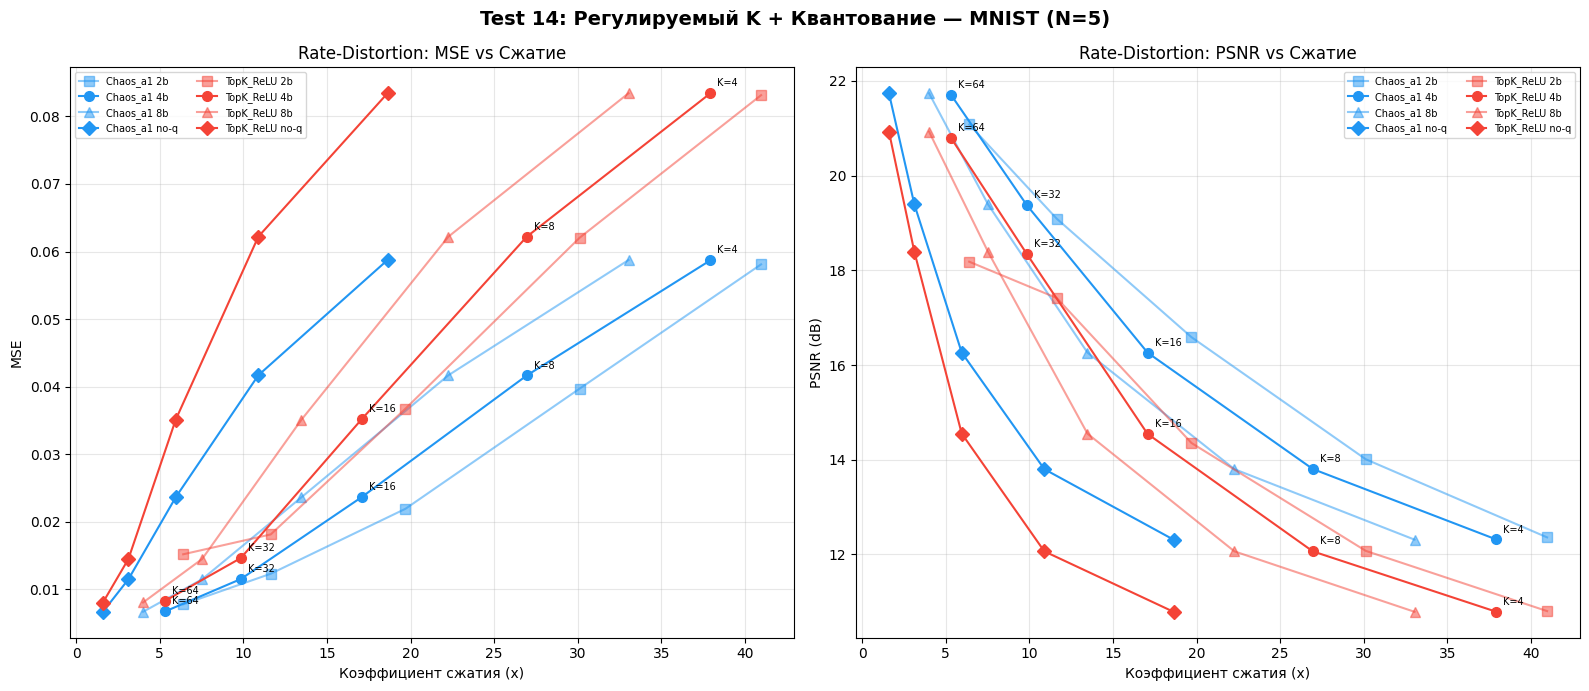

In [7]:
# === Rate-Distortion карта: все точки K×bits ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

arch_colors = {'Chaos_a1': '#2196F3', 'TopK_ReLU': '#F44336'}
bit_markers = {2: 's', 4: 'o', 8: '^', 32: 'D'}

for arch_name in architectures:
    for bits in BIT_LEVELS:
        crs = [summary[arch_name][k][bits]['cr'] for k in TEST_K_VALUES]
        mses = [summary[arch_name][k][bits]['mse_mean'] for k in TEST_K_VALUES]
        psnrs = [summary[arch_name][k][bits]['psnr_mean'] for k in TEST_K_VALUES]

        label = f"{arch_name} {bits}b" if bits != 32 else f"{arch_name} no-q"
        alpha = 1.0 if bits in [4, 32] else 0.5

        axes[0].plot(crs, mses, color=arch_colors[arch_name],
                    marker=bit_markers[bits], linewidth=1.5, markersize=7,
                    label=label, alpha=alpha)

        axes[1].plot(crs, psnrs, color=arch_colors[arch_name],
                    marker=bit_markers[bits], linewidth=1.5, markersize=7,
                    label=label, alpha=alpha)

        # Подписи K
        for i, k in enumerate(TEST_K_VALUES):
            if bits == 4:
                axes[0].annotate(f'K={k}', (crs[i], mses[i]),
                                textcoords="offset points", xytext=(5, 5), fontsize=7)
                axes[1].annotate(f'K={k}', (crs[i], psnrs[i]),
                                textcoords="offset points", xytext=(5, 5), fontsize=7)

axes[0].set_xlabel('Коэффициент сжатия (x)')
axes[0].set_ylabel('MSE')
axes[0].set_title('Rate-Distortion: MSE vs Сжатие')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Коэффициент сжатия (x)')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Rate-Distortion: PSNR vs Сжатие')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Test 14: Регулируемый K + Квантование — MNIST (N={NUM_RUNS})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

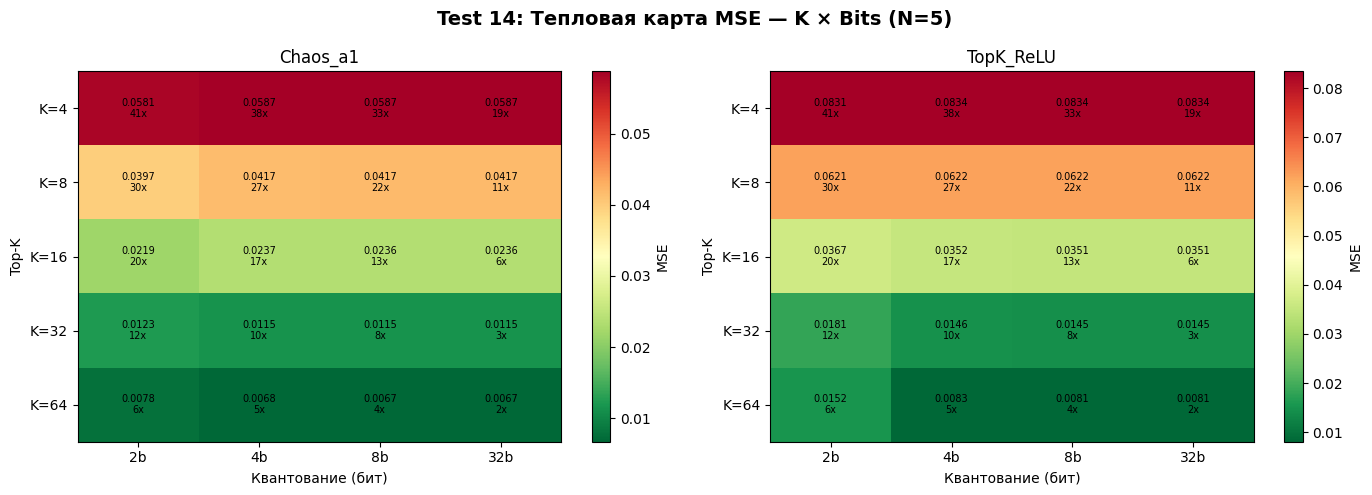

In [8]:
# === Тепловая карта: K vs Bits → MSE ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, arch_name in enumerate(architectures):
    matrix = np.zeros((len(TEST_K_VALUES), len(BIT_LEVELS)))
    for i, k in enumerate(TEST_K_VALUES):
        for j, bits in enumerate(BIT_LEVELS):
            matrix[i, j] = summary[arch_name][k][bits]['mse_mean']

    im = axes[idx].imshow(matrix, cmap='RdYlGn_r', aspect='auto')
    axes[idx].set_xticks(range(len(BIT_LEVELS)))
    axes[idx].set_xticklabels([f'{b}b' for b in BIT_LEVELS])
    axes[idx].set_yticks(range(len(TEST_K_VALUES)))
    axes[idx].set_yticklabels([f'K={k}' for k in TEST_K_VALUES])
    axes[idx].set_xlabel('Квантование (бит)')
    axes[idx].set_ylabel('Top-K')
    axes[idx].set_title(arch_name)

    for i in range(len(TEST_K_VALUES)):
        for j in range(len(BIT_LEVELS)):
            cr = summary[arch_name][TEST_K_VALUES[i]][BIT_LEVELS[j]]['cr']
            axes[idx].text(j, i, f'{matrix[i,j]:.4f}\n{cr:.0f}x',
                          ha='center', va='center', fontsize=7)

    plt.colorbar(im, ax=axes[idx], label='MSE')

plt.suptitle(f'Test 14: Тепловая карта MSE — K × Bits (N={NUM_RUNS})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Обучение модели для визуализации...


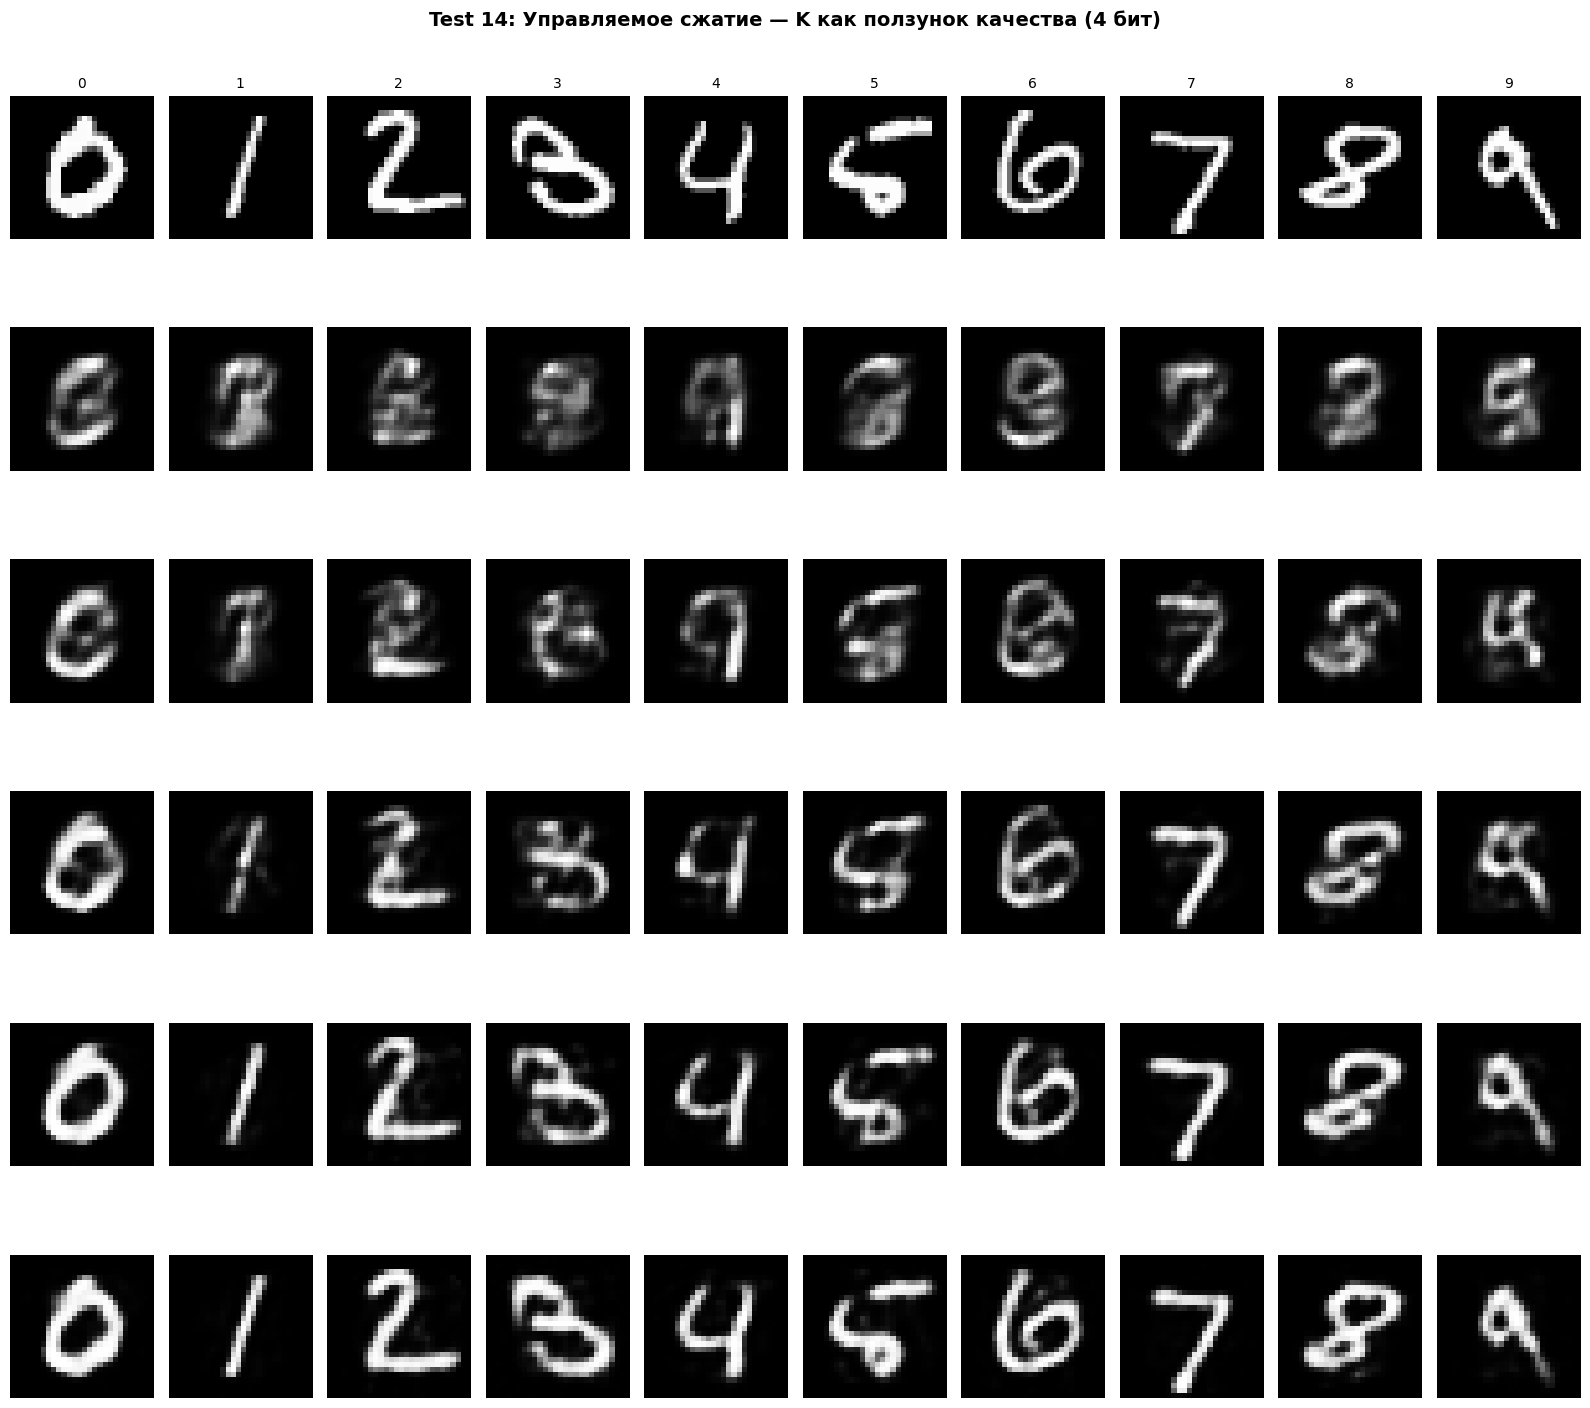

Done.


In [9]:
# === Визуализация: разные K при 4 битах ===
print("Обучение модели для визуализации...")
np.random.seed(0)
tf.random.set_seed(0)
ae_viz, enc_viz = build_chaos_ae(latent_dim=LATENT_DIM, k_active=TRAIN_K, a=1.0)
ae_viz.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

full_latents_viz = enc_viz.predict(x_test, verbose=0)

# Декодер
decoder_input = keras.Input(shape=(LATENT_DIM,))
x = decoder_input
found_latent = False
for layer in ae_viz.layers:
    if layer.name == 'latent_ksparse':
        found_latent = True
        continue
    if found_latent:
        x = layer(x)
decoder_viz = keras.Model(decoder_input, x)

sample_indices = [np.where(y_test == d)[0][0] for d in range(10)]
samples = x_test[sample_indices]
sample_latents = full_latents_viz[sample_indices]

viz_k_values = [4, 8, 16, 32, 64]
QUANT_BITS = 4

fig, axes = plt.subplots(len(viz_k_values) + 1, 10,
                         figsize=(16, 2.5 * (len(viz_k_values) + 1)))

# Оригиналы
for i in range(10):
    axes[0, i].imshow(samples[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(str(i), fontsize=10)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9, rotation=0, labelpad=70)

for row, k in enumerate(viz_k_values, 1):
    sparse_lat = apply_topk(sample_latents, k)
    q_lat = quantize_sparse(sparse_lat, QUANT_BITS, k)
    recons = decoder_viz.predict(q_lat, verbose=0)
    cr = compression_ratio(LATENT_DIM, k, QUANT_BITS)

    for i in range(10):
        axes[row, i].imshow(recons[i, :, :, 0], cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'K={k}, 4b\n{cr:.0f}x', fontsize=9, rotation=0, labelpad=70)

plt.suptitle('Test 14: Управляемое сжатие — K как ползунок качества (4 бит)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

del ae_viz, enc_viz, decoder_viz
keras.backend.clear_session()
print("Done.")

Обучение ReLU модели для визуализации...


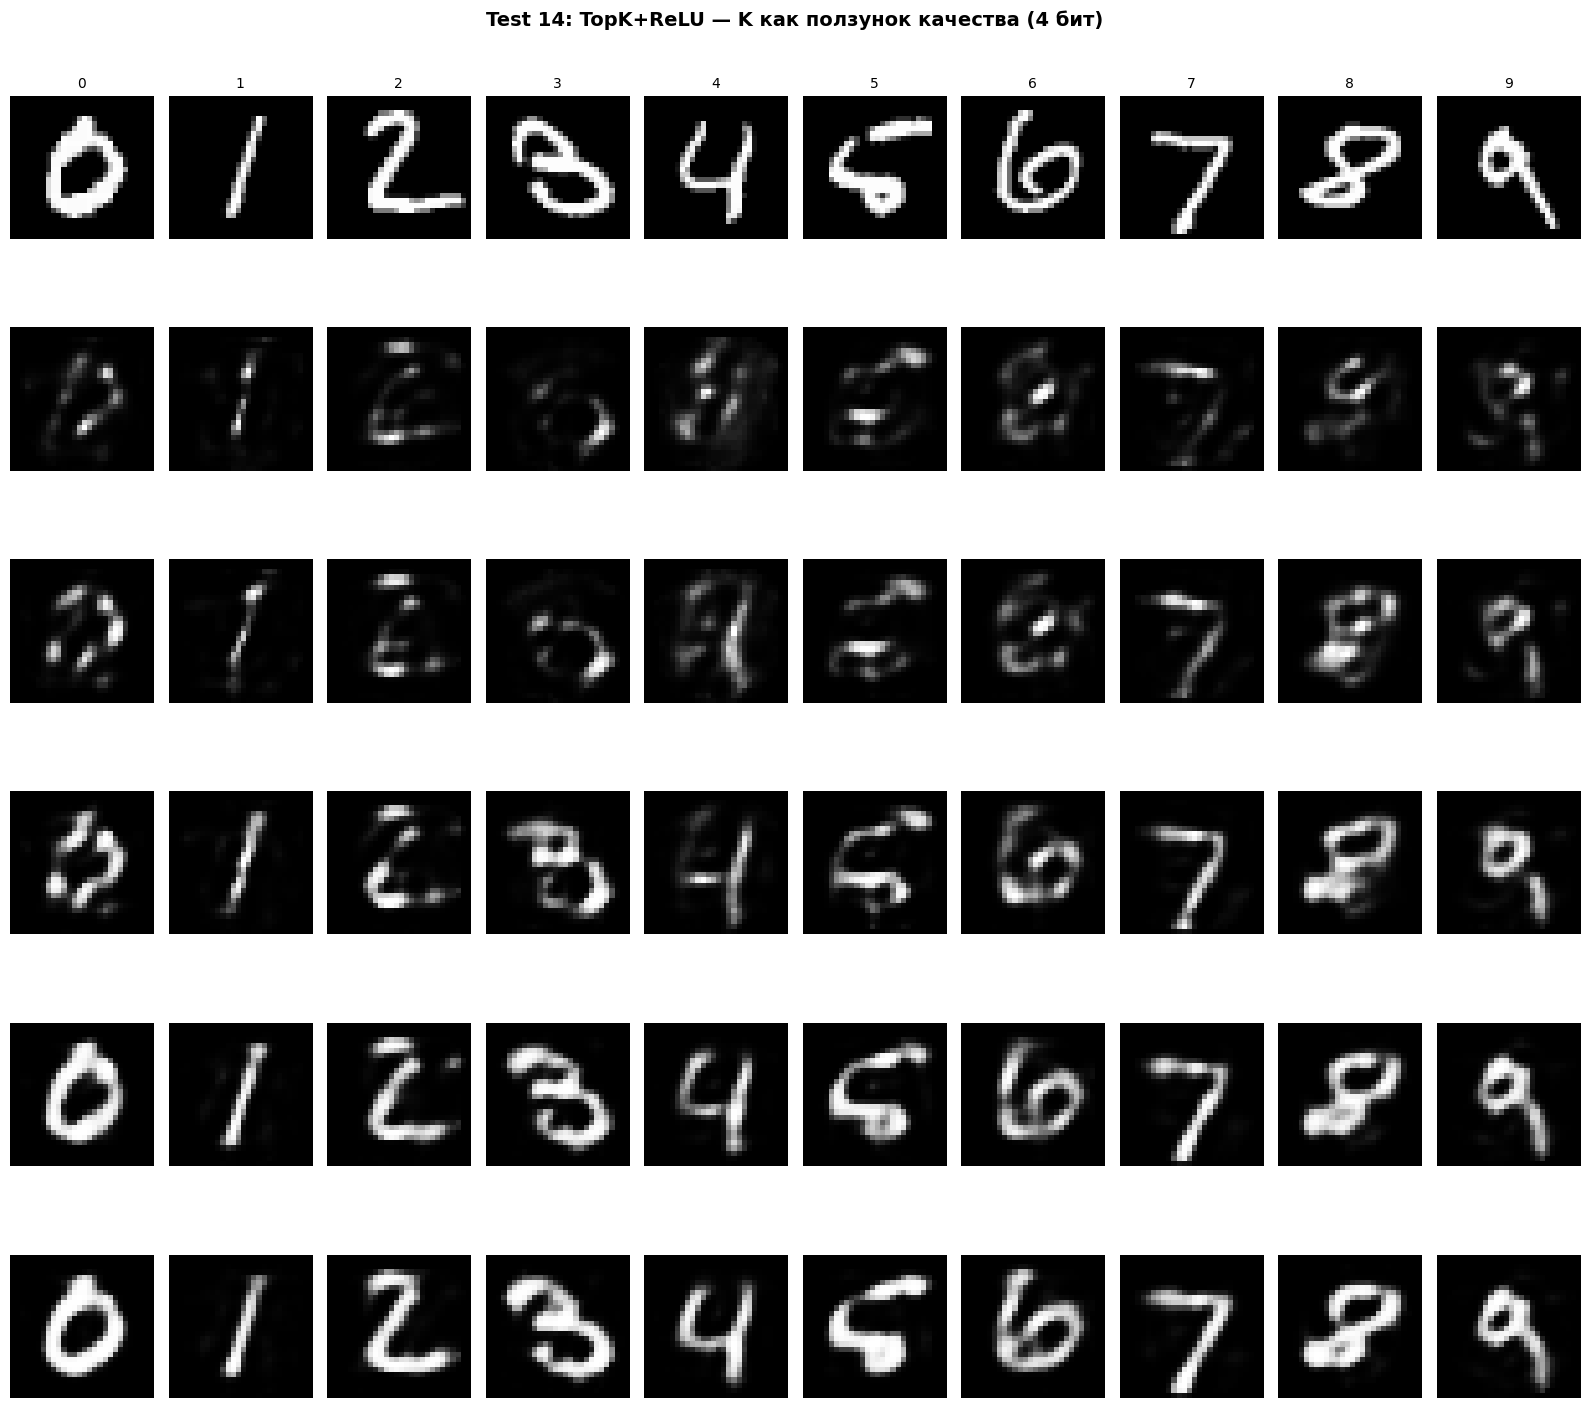

Done.


In [11]:
# === Визуализация: разные K при 4 битах — TopK+ReLU ===
print("Обучение ReLU модели для визуализации...")
np.random.seed(0)
tf.random.set_seed(0)
ae_viz, enc_viz = build_topk_relu(latent_dim=LATENT_DIM, k_active=TRAIN_K)
ae_viz.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

full_latents_viz = enc_viz.predict(x_test, verbose=0)

# Декодер
decoder_input = keras.Input(shape=(LATENT_DIM,))
x = decoder_input
found_latent = False
for layer in ae_viz.layers:
    if layer.name == 'latent_ksparse':
        found_latent = True
        continue
    if found_latent:
        x = layer(x)
decoder_viz = keras.Model(decoder_input, x)

sample_indices = [np.where(y_test == d)[0][0] for d in range(10)]
samples = x_test[sample_indices]
sample_latents = full_latents_viz[sample_indices]

viz_k_values = [4, 8, 16, 32, 64]
QUANT_BITS = 4

fig, axes = plt.subplots(len(viz_k_values) + 1, 10,
                         figsize=(16, 2.5 * (len(viz_k_values) + 1)))

# Оригиналы
for i in range(10):
    axes[0, i].imshow(samples[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(str(i), fontsize=10)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9, rotation=0, labelpad=70)

for row, k in enumerate(viz_k_values, 1):
    sparse_lat = apply_topk(sample_latents, k)
    q_lat = quantize_sparse(sparse_lat, QUANT_BITS, k)
    recons = decoder_viz.predict(q_lat, verbose=0)
    cr = compression_ratio(LATENT_DIM, k, QUANT_BITS)

    for i in range(10):
        axes[row, i].imshow(recons[i, :, :, 0], cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'K={k}, 4b\n{cr:.0f}x', fontsize=9, rotation=0, labelpad=70)

plt.suptitle('Test 14: TopK+ReLU — K как ползунок качества (4 бит)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

del ae_viz, enc_viz, decoder_viz
keras.backend.clear_session()
print("Done.")


In [10]:
# === Сохранение результатов ===
save_data = {
    'experiment': 'adaptive_k_quantization',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'dataset': 'MNIST',
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'latent_dim': LATENT_DIM,
        'train_k': TRAIN_K,
        'test_k_values': TEST_K_VALUES,
        'bit_levels': BIT_LEVELS,
    },
    'results': results,
}

json_path = f'../jsons/adaptive_k_quant_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/adaptive_k_quant_20260406_181940.json
